# Calibration Rote==0 and Non removing q=0s

In [7]:
import os
import numpy as np
import geopandas as gpd
from pyproj import CRS

# 1. Load your GeoDataFrame
df_routes = gpd.read_file('input/network_edges_with_attributes_fixed_remove_duplicate_options_v1.gpkg')
df_routes = df_routes.fillna(0)

# 2. Rename columns to match C-Logit coefficient names
df_routes = df_routes.rename(columns={
    'gradient_weighted': 'gradiant',
    'poi': 'pois',
    'gvi': 'green_views_index',
    'cf': 'commonality_factor',
    'od': 'trip_id'  # We'll treat 'od' as the unique trip identifier
})

# 3. Apply C-Logit Model with fixed coefficients
def inference_c_logit(df):
    beta = {
        'distance': -0.0005,
        'turns': -0.11,
        'crossings': -0.001,
        'gradiant': -0.16,
        'pois': 0.001,
        'green_views_index': 0.003,
        'commonality_factor': 0.65
    }

    df['V'] = (
        beta['distance'] * df['distance'] +
        beta['turns'] * df['turns'] +
        beta['crossings'] * df['crossings'] +
        beta['gradiant'] * df['gradiant'] +
        beta['pois'] * df['pois'] +
        beta['green_views_index'] * df['green_views_index']
    )

    df['V_c'] = df['V'] + beta['commonality_factor'] * df['commonality_factor']
    df['expV'] = np.exp(df['V_c'])

    df['sum_expV'] = df.groupby('trip_id')['expV'].transform('sum')
    df['prob'] = df['expV'] / df['sum_expV']

    return df

df_routes = inference_c_logit(df_routes)



# print("✅ C-Logit probabilities computed and files exported successfully.")
os.makedirs("output", exist_ok=True)

df_routes.to_file(
    "output/walking_trips_output_clogit_keepzeroOD.geojson",
    driver="GeoJSON",
    index=False
)


In [8]:
import pandas as pd

# 1. Load OD demand and mapping data
demand = pd.read_csv('input/Sydney_OD_hybrid_predicted_Transfered_Sydney_NegBin_Seattle_v1.csv')
od_nodes = pd.read_csv('input/Sydney_OD_with_shortest_path_fixed_v1.csv')



# 2. Merge to get origin and destination nodes for each OD pair
demand_nodes = (
    demand.merge(
        od_nodes,
        on=['ORIGSA1_2021', 'DESTSA1_2021'],
        how='left'
    )
)

# Rename for consistency with df_routes
demand_nodes = demand_nodes.rename(columns={
    'Origin_Node': 'origin_node',
    'Destination_Node': 'destination_node'
})


# 3. Merge with df_routes to assign demand to each route
# Make sure df_routes is a DataFrame (if it's still a GeoDataFrame, this is fine)
df_routes = df_routes.merge(
    demand_nodes,
    on=['origin_node', 'destination_node'],
    how='left'
)

# 4. Multiply demand by route probability to get flow per route
df_routes['route_flow'] = df_routes['prob'] * df_routes['Predicted_Flow']

# 5. (Optional) Fill NaNs in case some OD pairs are missing
df_routes['route_flow'] = df_routes['route_flow'].fillna(0)

# 6. Export to GeoJSON and CSV
os.makedirs("output", exist_ok=True)
df_routes.to_file("output/walking_trips_with_route_flows_clogit_keepzeroOD.geojson", driver="GeoJSON")

print("✅ Route-level flows computed and exported successfully.")


✅ Route-level flows computed and exported successfully.


# OD adjustment with Delta==0.001

Number of counting sites |I|: 103
Number of unique OD pairs |Z| (including zero ODs): 622
Total prior demand sum(q0): 31367.369401860524
Exploding routes into segments...
Number of route segments: 118222
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.0095e+08                                    1.06e+06    
       1              2         3.9790e+08      3.04e+06       3.42e+03       2.62e+05    
       2              3         3.9705e+08      8.55e+05       1.80e+03       5.75e+04    
       3              4         3.9652e+08      5.28e+05       1.39e+03       1.80e+03    
       4              5         3.9548e+08      1.04e+06       2.22e+02       1.78e+03    
       5              6         3.9485e+08      6.33e+05       1.38e+02       1.77e+03    
       6              7         3.9434e+08      5.10e+05       1.13e+02       1.76e+03    
       7              8         3.9383e+08      5.16e+05       1.51e

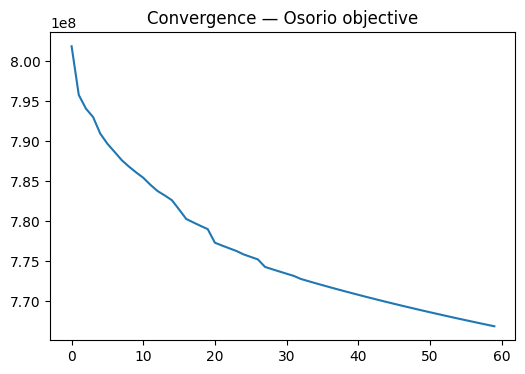

In [10]:
# =====================================================
# OD DEMAND CALIBRATION — OSORIO (2019), PROBLEM (1)–(2)
# KEEP ZERO ODs (DO NOT REMOVE)
# =====================================================

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString, MultiLineString
from scipy import sparse
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# -----------------------------
# USER SETTINGS
# -----------------------------
SITE_ID_COL = "SiteID"
DELTA = 0.001
MAX_NFEV = 60

USE_UPPER_BOUNDS = False
DMAX = None
EPS = 1e-12

ROUTES_PATH = "output/walking_trips_with_route_flows_clogit_keepzeroOD.geojson"
OBS_NET_PATH = "input/network_with_sites_counts_2025_autumn_v1.gpkg"

# =====================================================
# 1) LOAD DATA
# =====================================================
df_routes = gpd.read_file(ROUTES_PATH)
obs_net   = gpd.read_file(OBS_NET_PATH)

if obs_net.crs != df_routes.crs:
    obs_net = obs_net.to_crs(df_routes.crs)

if "TotalCount" in obs_net.columns and "flow_obs" not in obs_net.columns:
    obs_net = obs_net.rename(columns={"TotalCount": "flow_obs"})

# =====================================================
# 2) OBSERVED COUNTS y
# =====================================================
obs_sites = (
    obs_net
    .dissolve(by=SITE_ID_COL, aggfunc={"flow_obs": "first"})
    .reset_index()
)

y = obs_sites["flow_obs"].astype(float).to_numpy().copy()

site_ids  = obs_sites[SITE_ID_COL].tolist()
site_to_i = {sid: i for i, sid in enumerate(site_ids)}
I = len(y)

print("Number of counting sites |I|:", I)

# =====================================================
# 3) OD KEY + NORMALIZE ROUTE PROBABILITIES PER OD
# =====================================================
df_routes = df_routes.dropna(subset=["Predicted_Flow", "prob"]).copy()

df_routes["origin_node"] = df_routes["origin_node"].astype(str)
df_routes["destination_node"] = df_routes["destination_node"].astype(str)

df_routes["u"] = df_routes[["origin_node", "destination_node"]].min(axis=1)
df_routes["v"] = df_routes[["origin_node", "destination_node"]].max(axis=1)
df_routes["od_key"] = list(zip(df_routes["u"], df_routes["v"]))

df_routes["prob"] = df_routes.groupby("od_key")["prob"].transform(
    lambda x: x / (x.sum() + EPS)
)

# =====================================================
# 4) PRIOR OD VECTOR q0 (KEEP ZERO ODs)
# =====================================================
if "route" in df_routes.columns:
    df_od0 = df_routes[df_routes["route"] == 0].copy()

    all_ods = set(df_routes["od_key"].unique())
    od0_ods = set(df_od0["od_key"].unique())
    missing_ods = all_ods - od0_ods

    if len(missing_ods) > 0:
        fallback = (
            df_routes[df_routes["od_key"].isin(missing_ods)]
            .drop_duplicates("od_key", keep="first")
        )
        df_od0 = pd.concat([df_od0, fallback], axis=0, ignore_index=True)

else:
    df_od0 = df_routes.drop_duplicates("od_key", keep="first").copy()

q0_series = (
    df_od0
    .set_index("od_key")["Predicted_Flow"]
    .astype(float)
    .sort_index()
)

# ✅ KEEP ZERO ODs (no filtering)
od_keys = q0_series.index.tolist()
od_to_j = {od: j for j, od in enumerate(od_keys)}

q0 = q0_series.to_numpy()

# stabilise pure zeros for optimisation (does NOT force demand)
q0 = np.maximum(q0, EPS)

Z = len(q0)

print("Number of unique OD pairs |Z| (including zero ODs):", Z)
print("Total prior demand sum(q0):", float(q0.sum()))

# =====================================================
# 5) ROUTE → SITE INCIDENCE USING BUFFERED INTERSECTION
# =====================================================
BUFFER_TOL = 5  # CRS units; adjust if needed

def explode_route_to_segments(route_geom, route_idx):
    rows = []

    if route_geom is None or route_geom.is_empty:
        return rows

    if isinstance(route_geom, LineString):
        lines = [route_geom]
    elif isinstance(route_geom, MultiLineString):
        lines = list(route_geom.geoms)
    else:
        return rows

    seg_id = 0
    for ln in lines:
        coords = list(ln.coords)
        for p1, p2 in zip(coords[:-1], coords[1:]):
            seg = LineString([p1, p2])
            if seg.length > 0:
                rows.append({
                    "route_idx": route_idx,
                    "seg_id": seg_id,
                    "geometry": seg
                })
                seg_id += 1

    return rows


print("Exploding routes into segments...")

seg_rows = []
for ridx, geom in enumerate(df_routes.geometry):
    seg_rows.extend(explode_route_to_segments(geom, ridx))

route_segments = gpd.GeoDataFrame(seg_rows, geometry="geometry", crs=df_routes.crs)

print("Number of route segments:", len(route_segments))


# buffer route segments slightly to allow small geometry mismatch
route_segments_match = route_segments.copy()
route_segments_match["geometry"] = route_segments_match.geometry.buffer(BUFFER_TOL)

# make sure obs_sites has stable row index
obs_sites = obs_sites.reset_index(drop=True).copy()
obs_sites["site_idx"] = np.arange(len(obs_sites))

matches = gpd.sjoin(
    route_segments_match,
    obs_sites[[SITE_ID_COL, "site_idx", "geometry"]],
    how="inner",
    predicate="intersects"
)

route_to_sites = (
    matches[["route_idx", SITE_ID_COL]]
    .drop_duplicates()
    .groupby("route_idx")[SITE_ID_COL]
    .apply(list)
    .to_dict()
)

df_routes["site_ids"] = df_routes.index.map(
    lambda ridx: route_to_sites.get(ridx, [])
)


# =====================================================
# 6) BUILD A MATRIX A (ALL ODs KEPT)
# =====================================================
rows, cols, data = [], [], []

for ridx, r in df_routes.iterrows():
    od = r["od_key"]
    if od not in od_to_j:
        continue

    j = od_to_j[od]
    prob = float(r["prob"])

    if prob <= 0:
        continue

    for sid in r["site_ids"]:
        if sid not in site_to_i:
            continue

        i = site_to_i[sid]
        rows.append(i)
        cols.append(j)
        data.append(prob)

A = sparse.csr_matrix((data, (rows, cols)), shape=(I, Z))

row_nnz = np.diff(A.indptr)


# =====================================================
# 7) OSORIO OBJECTIVE VIA AUGMENTED RESIDUALS
# =====================================================
w_y = np.sqrt(1.0 / I)
w_q = np.sqrt(DELTA / Z)

A_aug = sparse.vstack(
    [w_y * A, w_q * sparse.identity(Z, format="csr")],
    format="csr"
)
b_aug = np.concatenate([w_y * y, w_q * q0])

def objective_osorio(qk):
    return (1.0 / I) * np.sum((A @ qk - y) ** 2) + (DELTA / Z) * np.sum((qk - q0) ** 2)

# =====================================================
# 8) SOLVE
# =====================================================
lb = np.zeros(Z)
ub = np.full(Z, np.inf)

x0 = np.maximum(q0, 0.0)

history = []
_last_x = {"x": None}

def residual_logged(q):
    xp = _last_x["x"]
    if xp is None or not np.array_equal(q, xp):
        history.append(objective_osorio(q))
        _last_x["x"] = q.copy()
    return (A_aug @ q) - b_aug

def jac(_q):
    return A_aug

res = least_squares(
    residual_logged,
    x0=x0,
    jac=jac,
    bounds=(lb, ub),
    method="trf",
    max_nfev=MAX_NFEV,
    ftol=1e-9, xtol=1e-9, gtol=1e-9,
    verbose=2
)

q_hat = np.maximum(res.x, 0.0)

# =====================================================
# 9) RESULTS
# =====================================================
y_hat = A @ q_hat
J_final = objective_osorio(q_hat)

print("\n=== OBJECTIVE VALUE (Osorio, 2019) ===")
print("J =", float(J_final))

print("\nTotal prior demand     =", float(q0.sum()))
print("Total calibrated demand=", float(q_hat.sum()))

# =====================================================
# 10) WRITE BACK
# =====================================================
df_routes["OD_demand_cal"] = df_routes["od_key"].map(
    lambda od: q_hat[od_to_j[od]]
)

df_routes["route_flow_cal"] = df_routes["OD_demand_cal"] * df_routes["prob"]

# =====================================================
# 11) PLOTS
# =====================================================
plt.figure(figsize=(6,4))
plt.plot(history)
plt.title("Convergence — Osorio objective")
plt.show()

In [11]:
# =====================================================
# SITE-LEVEL METRICS (CALIBRATION SPACE: y vs A q)
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EPS = 1e-9

y_obs  = y.astype(float)
y_pred = y_hat.astype(float)

def geh(pred, obs):
    return np.sqrt(2.0 * (pred - obs) ** 2 / (pred + obs + EPS))

metrics_calibration = {
    "N_sites": len(y_obs),
    "MAE": np.mean(np.abs(y_pred - y_obs)),
    "RMSE": np.sqrt(np.mean((y_pred - y_obs) ** 2)),
    "MAPE (%)": np.mean(
        np.abs((y_pred - y_obs) / np.maximum(y_obs, EPS))
    ) * 100,
    "R2": (
        np.corrcoef(y_pred, y_obs)[0, 1] ** 2
        if y_pred.std() > EPS and y_obs.std() > EPS
        else np.nan
    ),
    "GEH < 5 (%)": (geh(y_pred, y_obs) < 5).mean() * 100,
    "GEH < 10 (%)": (geh(y_pred, y_obs) < 10).mean() * 100,
}

metrics_calibration = pd.Series(metrics_calibration)

print("\n📊 SITE-LEVEL METRICS (CALIBRATION SPACE: y vs A q)")
print(metrics_calibration.round(3))



📊 SITE-LEVEL METRICS (CALIBRATION SPACE: y vs A q)
N_sites         1.030000e+02
MAE             1.655004e+04
RMSE            2.769254e+04
MAPE (%)        1.556110e+13
R2              2.700000e-02
GEH < 5 (%)     0.000000e+00
GEH < 10 (%)    0.000000e+00
dtype: float64


# Graph features

Directed graph (q0)  : 154 nodes, 93 edges
Directed graph (qhat): 487 nodes, 582 edges

Merged directed weights:
  origin_node destination_node  weight_q0    weight_qhat       diff
0       10011            10079        NaN   4.391179e-97        NaN
1       10011             5650        NaN   3.036410e+01        NaN
2       10011             7403  72.809525   4.774302e-94 -72.809525
3       10047              199        NaN  6.331394e-106        NaN
4       10047              331        NaN   7.613434e+01        NaN


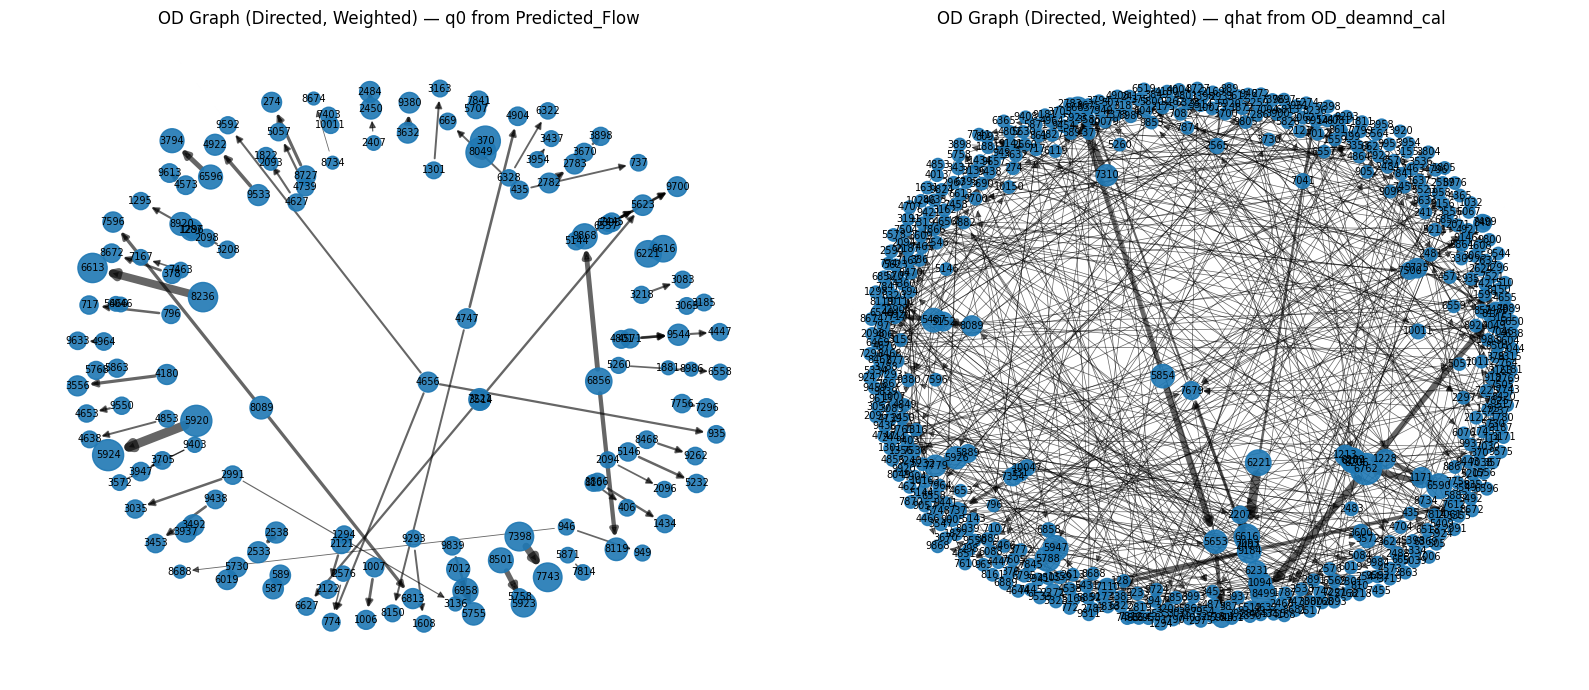

In [12]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------------
# Build directed OD weights directly from route == 0
# -----------------------------
def build_directed_od_weights_from_columns(df_routes, weight_col, route_col="route", route_value=0):
    """
    Build directed OD weights directly from df_routes using:
    - origin_node
    - destination_node
    - weight_col

    Only rows with route == route_value are used.
    """

    df = df_routes[df_routes[route_col] == route_value].copy()
    df["origin_node"] = df["origin_node"].astype(str)
    df["destination_node"] = df["destination_node"].astype(str)

    directed_weights = (
        df.groupby(["origin_node", "destination_node"], as_index=False)[weight_col]
        .sum()
        .rename(columns={weight_col: "weight"})
    )

    # keep only positive weights
    directed_weights = directed_weights[directed_weights["weight"] > 0].copy()

    return directed_weights


# -----------------------------
# Convert to directed graph
# -----------------------------
def weights_to_digraph(directed_weights_df):
    G = nx.DiGraph()

    for o, d, w in directed_weights_df[["origin_node", "destination_node", "weight"]].itertuples(index=False):
        if o == d:
            continue

        if G.has_edge(o, d):
            G[o][d]["weight"] += float(w)
        else:
            G.add_edge(o, d, weight=float(w))

    return G


# -----------------------------
# Plot helper
# -----------------------------
def plot_weighted_digraph(G, ax, title, seed=7):
    if G.number_of_nodes() == 0:
        ax.set_title(title + " (empty)")
        ax.axis("off")
        return

    pos = nx.spring_layout(G, seed=seed)

    # edge widths scaled by weight
    weights = np.array([G[u][v]["weight"] for u, v in G.edges()])
    wmax = weights.max() if len(weights) else 1.0
    widths = 0.5 + 6.0 * (weights / (wmax + 1e-12))**0.5

    # node size by weighted degree
    strength = dict(G.degree(weight="weight"))
    svals = np.array(list(strength.values()))
    smax = svals.max() if len(svals) else 1.0
    sizes = [80 + 420 * (strength[n] / (smax + 1e-12))**0.5 for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes, alpha=0.9)
    nx.draw_networkx_edges(G, pos, ax=ax, width=widths, alpha=0.6, arrows=True, arrowsize=10)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7)

    ax.set_title(title)
    ax.axis("off")


# -----------------------------
# Build q0 and qhat directly
# -----------------------------
dw_q0 = build_directed_od_weights_from_columns(
    df_routes,
    weight_col="Predicted_Flow"
)

dw_qhat = build_directed_od_weights_from_columns(
    df_routes,
    weight_col="OD_demand_cal"
)

G0 = weights_to_digraph(dw_q0)
Ghat = weights_to_digraph(dw_qhat)

print("Directed graph (q0)  :", G0.number_of_nodes(), "nodes,", G0.number_of_edges(), "edges")
print("Directed graph (qhat):", Ghat.number_of_nodes(), "nodes,", Ghat.number_of_edges(), "edges")


# -----------------------------
# Compare q0 and qhat
# -----------------------------
merged_dw = dw_q0.merge(
    dw_qhat,
    on=["origin_node", "destination_node"],
    how="outer",
    suffixes=("_q0", "_qhat")
)

merged_dw["weight_q0"] = merged_dw["weight_q0"].fillna(np.nan)
merged_dw["weight_qhat"] = merged_dw["weight_qhat"].fillna(np.nan)
merged_dw["diff"] = merged_dw["weight_qhat"] - merged_dw["weight_q0"]

print("\nMerged directed weights:")
print(merged_dw.head())


# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_weighted_digraph(G0, axes[0], "OD Graph (Directed, Weighted) — q0 from Predicted_Flow")
plot_weighted_digraph(Ghat, axes[1], "OD Graph (Directed, Weighted) — qhat from OD_deamnd_cal")

plt.tight_layout()
plt.show()

In [14]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------------
# Build directed OD weights directly from route == 0
# -----------------------------
def build_directed_od_weights_from_columns(
    df_routes,
    weight_col,
    route_col="route",
    route_value=0
):
    """
    Build directed OD weights directly from df_routes using:
    - origin_node
    - destination_node
    - weight_col

    Only rows with route == route_value are used.
    """
    df = df_routes[df_routes[route_col] == route_value].copy()

    df["origin_node"] = df["origin_node"].astype(str)
    df["destination_node"] = df["destination_node"].astype(str)

    directed_weights = (
        df.groupby(
            ["origin_node", "destination_node"],
            as_index=False
        )[weight_col]
        .sum(min_count=1)
        .rename(columns={weight_col: "weight"})
    )

    return directed_weights


# -----------------------------
# Convert NaN + epsilon values to zero BEFORE merging
# -----------------------------
def clean_weights_before_merge(dw, epsilon=1e-12):
    dw = dw.copy()

    # fill NaN with zero
    dw["weight"] = dw["weight"].fillna(0)

    # convert epsilon and very small values to zero
    dw.loc[np.abs(dw["weight"]) <= epsilon, "weight"] = 0

    return dw


# -----------------------------
# Convert to directed graph
# -----------------------------
def weights_to_digraph(directed_weights_df):
    G = nx.DiGraph()

    for o, d, w in directed_weights_df[
        ["origin_node", "destination_node", "weight"]
    ].itertuples(index=False):

        if o == d:
            continue

        if pd.isna(w):
            continue

        if G.has_edge(o, d):
            G[o][d]["weight"] += float(w)
        else:
            G.add_edge(o, d, weight=float(w))

    return G


# -----------------------------
# Build q0 and qhat from route == 0
# -----------------------------
epsilon = 1e-10

dw_q0 = build_directed_od_weights_from_columns(
    df_routes,
    weight_col="Predicted_Flow",
    route_col="route",
    route_value=0
)

dw_q0["weight"] = dw_q0["weight"] * 0.06

dw_q0 = clean_weights_before_merge(
    dw_q0,
    epsilon=epsilon
)

dw_qhat = build_directed_od_weights_from_columns(
    df_routes,
    weight_col="OD_demand_cal",
    route_col="route",
    route_value=0
)

dw_qhat = clean_weights_before_merge(
    dw_qhat,
    epsilon=epsilon
)

G0 = weights_to_digraph(dw_q0)
Ghat = weights_to_digraph(dw_qhat)

print(
    "Directed graph (q0):",
    G0.number_of_nodes(),
    "nodes,",
    G0.number_of_edges(),
    "edges"
)

print(
    "Directed graph (qhat):",
    Ghat.number_of_nodes(),
    "nodes,",
    Ghat.number_of_edges(),
    "edges"
)


# -----------------------------
# Compare q0 and qhat
# -----------------------------
merged_dw = dw_q0.merge(
    dw_qhat,
    on=["origin_node", "destination_node"],
    how="outer",
    suffixes=("_q0", "_qhat")
)

# fill NaNs created by outer merge with zero
merged_dw["weight_q0"] = merged_dw["weight_q0"].fillna(0)
merged_dw["weight_qhat"] = merged_dw["weight_qhat"].fillna(0)

# convert epsilon values to zero again after merge
merged_dw.loc[
    np.abs(merged_dw["weight_q0"]) <= epsilon,
    "weight_q0"
] = 0

merged_dw.loc[
    np.abs(merged_dw["weight_qhat"]) <= epsilon,
    "weight_qhat"
] = 0

merged_dw["diff"] = (
    merged_dw["weight_qhat"]
    - merged_dw["weight_q0"]
)

merged_dw.loc[
    np.abs(merged_dw["diff"]) <= epsilon,
    "diff"
] = 0

print("\nMerged directed weights:")
print(merged_dw.head())

Directed graph (q0): 487 nodes, 582 edges
Directed graph (qhat): 487 nodes, 582 edges

Merged directed weights:
  origin_node destination_node  weight_q0  weight_qhat       diff
0       10011            10079   0.000000     0.000000   0.000000
1       10011             5650   0.000000    30.364102  30.364102
2       10011             7403   4.368571     0.000000  -4.368571
3       10047              199   0.000000     0.000000   0.000000
4       10047              331   0.000000    76.134342  76.134342


In [15]:
# directed graph features q=0

import networkx as nx
import numpy as np

def graph_features(G: nx.DiGraph):
    """
    Extended graph diagnostics WITHOUT removing epsilon edges.
    Uses the graph exactly as given.
    """

    # -------------------------------------------------
    # Basic size
    # -------------------------------------------------
    n = G.number_of_nodes()
    m = G.number_of_edges()

    if n <= 1:
        return {"nodes": n, "edges": m}

    # -------------------------------------------------
    # Degree + strength
    # -------------------------------------------------
    in_deg  = np.array([d for _, d in G.in_degree()])
    out_deg = np.array([d for _, d in G.out_degree()])
    strength = np.array([d for _, d in G.degree(weight="weight")])

    edge_weights = np.array([d["weight"] for _,_,d in G.edges(data=True)])

    # -------------------------------------------------
    # Reciprocity
    # -------------------------------------------------
    try:
        rec = nx.reciprocity(G)
    except:
        rec = np.nan

    # -------------------------------------------------
    # SCC stats
    # -------------------------------------------------
    sccs = list(nx.strongly_connected_components(G))
    num_scc = len(sccs)
    largest_scc = max((len(c) for c in sccs), default=0)

    # -------------------------------------------------
    # Clustering
    # -------------------------------------------------
    Gu = G.to_undirected()

    try:
        avg_clust = nx.average_clustering(Gu)
        avg_clust_weighted = nx.average_clustering(Gu, weight="weight")
    except:
        avg_clust = np.nan
        avg_clust_weighted = np.nan

    # -------------------------------------------------
    # Betweenness centrality (distance = inverse weight)
    # -------------------------------------------------
    try:
        H = G.copy()

        for u, v in H.edges():
            w = H[u][v].get("weight", 0.0)
            H[u][v]["dist"] = 1.0 / (w + 1e-12)

        bet = nx.betweenness_centrality(H, weight="dist", normalized=True)
        bet_vals = np.array(list(bet.values()))

        mean_bet = float(bet_vals.mean())
        max_bet  = float(bet_vals.max())
        std_bet  = float(bet_vals.std())
    except:
        mean_bet = np.nan
        max_bet  = np.nan
        std_bet  = np.nan

    # -------------------------------------------------
    # Shortest path length (largest SCC)
    # -------------------------------------------------
    try:
        WCC = max(nx.weakly_connected_components(G), key=len)
        S = G.subgraph(WCC).copy()

        for u, v in S.edges():
            w = S[u][v].get("weight",0.0)
            S[u][v]["dist"] = 1.0/(w + 1e-12)

        SCC = max(nx.strongly_connected_components(S), key=len)
        Ss = S.subgraph(SCC).copy()

        if Ss.number_of_nodes() > 1:
            asp = nx.average_shortest_path_length(Ss, weight="dist")
        else:
            asp = np.nan
    except:
        asp = np.nan

    # -------------------------------------------------
    # Strength inequality (hub dominance)
    # -------------------------------------------------
    gini_like = strength.max() / (strength.mean() + 1e-12)

    return {
        # topology
        "nodes": n,
        "edges": m,
        "density": nx.density(G),
        "reciprocity": rec,

        # degree / strength
        "avg_in_degree": float(in_deg.mean()),
        "avg_out_degree": float(out_deg.mean()),
        "avg_strength": float(strength.mean()),
        "std_strength": float(strength.std()),

        # clustering
        "avg_clustering_undirected": avg_clust,
        "avg_clustering_weighted": avg_clust_weighted,

        # betweenness (BEHAVIOUR CHANGE SIGNAL)
        "mean_betweenness": mean_bet,
        "max_betweenness": max_bet,
        "std_betweenness": std_bet,

        # flow inequality
        "gini_like_strength": gini_like,
        "mean_edge_weight": float(edge_weights.mean()),
        "std_edge_weight": float(edge_weights.std()),
        "max_edge_weight": float(edge_weights.max()),

        # connectivity
        "largest_scc_size": int(largest_scc),
        "num_scc": int(num_scc),

        # path behaviour
        "avg_shortest_path_len_invw_lcc": asp,
    }
feat0 = graph_features(G0)
featH = graph_features(Ghat)

df_feat = pd.DataFrame(
    [feat0, featH],
    index=["Before (q0)", "After (q̂)"]
).T

display(df_feat)

,Before (q0),After (q̂)
nodes,4.870000e+02,4.870000e+02
edges,5.820000e+02,5.820000e+02
density,2.458996e-03,2.458996e-03
reciprocity,5.498282e-02,5.498282e-02
avg_in_degree,1.195072e+00,1.195072e+00
avg_out_degree,1.195072e+00,1.195072e+00
avg_strength,7.729126e+00,7.556572e+01
std_strength,2.610427e+01,3.595812e+02
avg_clustering_undirected,4.262277e-02,4.262277e-02
avg_clustering_weighted,4.499402e-06,1.565766e-06
